In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

In [ ]:
len(words)

In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

In [ ]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
X.shape, X.dtype, Y.shape, Y.dtype

In [ ]:
C = torch.randn((27, 2))

In [ ]:
X.shape

In [ ]:
X

In [ ]:
emb = C[X]
emb.shape

In [ ]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [ ]:
emb.view(-1,6).shape

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [ ]:
h

In [ ]:
h.shape

In [ ]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [ ]:
logits = h @ W2 + b2

In [ ]:
logits.shape

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts / counts.sum(1, keepdims=True)

In [ ]:
prob.shape

In [ ]:
loss = -prob[torch.arange(prob.shape[0]), Y].log().mean()
loss

In [ ]:
# ------------ now made respectable :) ---------------

In [ ]:
Xtr.shape, Ytr.shape # dataset

In [200]:
# Hypeparams

block_size = 5 # context length: how many characters do we take to predict the next one?

embedings_feats = 10
emb_cols = block_size * embedings_feats  # 50
layer1_units = 300
batch_size = 64

In [201]:
# build the dataset

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182534, 5]) torch.Size([182534])
torch.Size([22873, 5]) torch.Size([22873])
torch.Size([22739, 5]) torch.Size([22739])


In [202]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((27, embedings_feats),  generator=g) * 0.1
W1 = torch.randn((emb_cols, layer1_units), generator=g) * (5/3) / (emb_cols ** 0.5)  # kaiming for tanh
b1 = torch.zeros(layer1_units)
W2 = torch.randn((layer1_units, 27),   generator=g) * 0.01
b2 = torch.zeros(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [203]:
sum(p.nelement() for p in parameters) # number of parameters in total

23697

In [204]:
print(len(parameters))

5


In [205]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [206]:
lri = []
lossi = []
stepi = []

In [207]:
iter = 300000
alpha_decay_at = int(iter * 0.85)
best_loss = float('inf')
best_params = [p.detach().clone() for p in parameters]

for i in range(iter):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  
  # forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, emb_cols) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  if loss.item() < best_loss:
    best_loss = loss.item()
    best_params = [p.detach().clone() for p in parameters]
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < alpha_decay_at else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  stepi.append(i)
  lossi.append(loss.log10().item())

print(f'best batch loss: {best_loss:.4f}')

best batch loss: 1.1231


In [210]:
best_loss

1.1231157779693604

In [211]:
C, W1, b1, W2, b2 = best_params

In [212]:
print(len(parameters[4]))

27


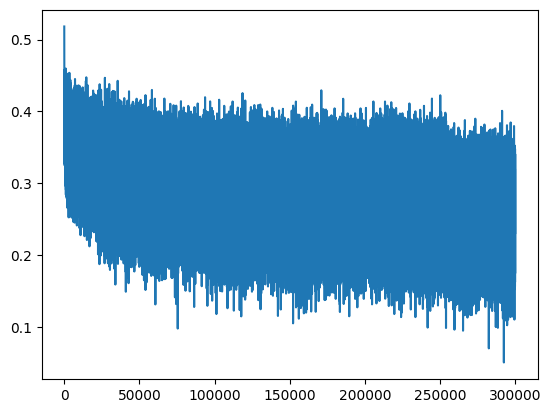

In [213]:
plt.plot(stepi, lossi)

In [214]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, emb_cols) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.8136)

In [215]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, emb_cols) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.0528)

In [216]:
emb = C[Xte]
h = torch.tanh(emb.view(-1,emb_cols) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.0642)

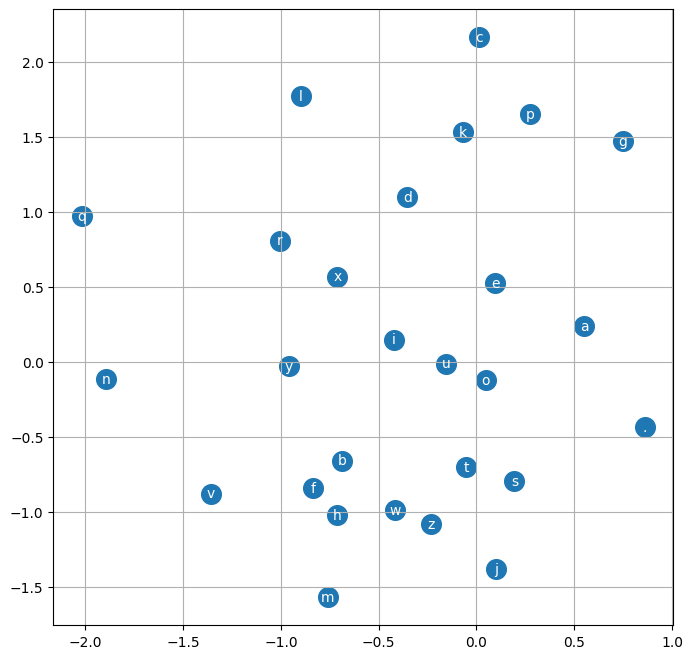

In [74]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [ ]:
context = [0] * block_size
C[torch.tensor([context])].shape

In [ ]:


# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))